# Dummy Performance Comparison

Compares Performance of `RazorsEdgeDummyTask` with `BaseBatchedDummyTask` under load.


In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()

while not (repo_root / "src").exists():
    if repo_root.parent == repo_root:
        raise RuntimeError("Could not find 'src' directory in any parent")
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [ ]:
import asyncio
import time
import matplotlib.pyplot as plt

from src.executor.process_manager import ComputeExecutor
from demos.synthetic import RazorsEdgeDummyTask
from demos.synthetic.base_batched_dummy_task import BaseBatchedDummyTask



## Start executor

In [3]:
executor = ComputeExecutor(
    [RazorsEdgeDummyTask, BaseBatchedDummyTask],
    async_limit=64,
    model_thread_limit=1,
)


## Basic functionality check

In [4]:
sample = executor.sync_compute_fn(RazorsEdgeDummyTask, "hello razors edge")
assert isinstance(sample, list)
assert len(sample) > 0
assert isinstance(sample[0], float)
print("sync check 1 passed")

sample = executor.sync_compute_fn(BaseBatchedDummyTask, "hello razors edge")
assert isinstance(sample, list)
assert len(sample) > 0
assert isinstance(sample[0], float)
print("sync check 2 passed")


sync check 1 passed
sync check 2 passed


## Benchmark helpers

In [5]:
import random
import string

def generate_random_strings(n, a, b, seed=42):
    random.seed(seed)  # set seed for reproducibility
    chars = string.ascii_letters + string.digits  # a-z, A-Z, 0-9
    result = []
    for _ in range(n):
        length = random.randint(a, b)
        rand_str = ''.join(random.choice(chars) for _ in range(length))
        result.append(rand_str)
    return result

async def benchmark_async(target, parallelism_limit: int, max_token_count: int, request_count: int) -> tuple[float, float]:
    payloads = generate_random_strings(request_count, 1, max_token_count)
    start = time.perf_counter()

    semaphore = asyncio.Semaphore(parallelism_limit)

    async def limited_task(*args, **kwargs):
        async with semaphore:
            return await executor.async_compute_fn(*args, **kwargs)

    await asyncio.gather(
        *(limited_task(target, payload) for payload in payloads)
    )
    elapsed = time.perf_counter() - start
    return elapsed, request_count / elapsed


## Run timing benchmarks

In [6]:
max_token_size = 1000
n_req = 200
parallelism_limits = [1, 2, 4, 8, 16, 32, 64]

razors_edge_rps_list = []
for parallelism_limit in parallelism_limits:
    a_elapsed, a_rps = await benchmark_async(RazorsEdgeDummyTask, parallelism_limit, max_token_size, n_req)
    razors_edge_rps_list.append(a_rps)
    print("Completeded one benchmark for RazorsEdgeDummyTask with parallelism_limit", parallelism_limit)


basic_rps_list = []
for parallelism_limit in parallelism_limits:
    a_elapsed, a_rps = await benchmark_async(BaseBatchedDummyTask, parallelism_limit, max_token_size, n_req)
    basic_rps_list.append(a_rps)
    print("Completeded one benchmark for BaseBatchedDummyTask with parallelism_limit", parallelism_limit)

Completeded one benchmark for RazorsEdgeDummyTask with parallelism_limit 1
Completeded one benchmark for RazorsEdgeDummyTask with parallelism_limit 2
Completeded one benchmark for RazorsEdgeDummyTask with parallelism_limit 4
Completeded one benchmark for RazorsEdgeDummyTask with parallelism_limit 8
Completeded one benchmark for RazorsEdgeDummyTask with parallelism_limit 16
Completeded one benchmark for RazorsEdgeDummyTask with parallelism_limit 32
Completeded one benchmark for RazorsEdgeDummyTask with parallelism_limit 64
Completeded one benchmark for BaseBatchedDummyTask with parallelism_limit 1
Completeded one benchmark for BaseBatchedDummyTask with parallelism_limit 2
Completeded one benchmark for BaseBatchedDummyTask with parallelism_limit 4
Completeded one benchmark for BaseBatchedDummyTask with parallelism_limit 8
Completeded one benchmark for BaseBatchedDummyTask with parallelism_limit 16
Completeded one benchmark for BaseBatchedDummyTask with parallelism_limit 32
Completeded on

## Matplotlib diagram 1: Throughput vs Load (Parallelism Limit)

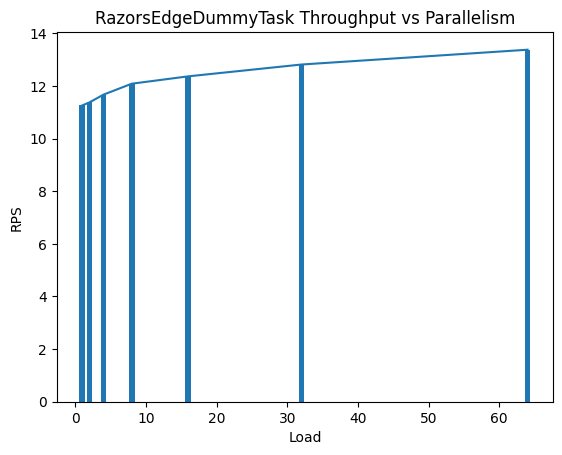

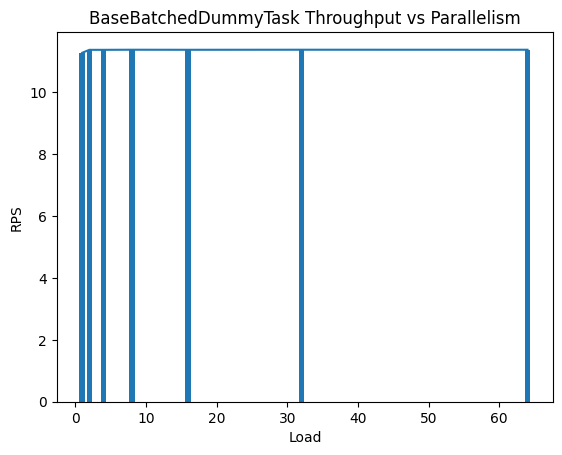

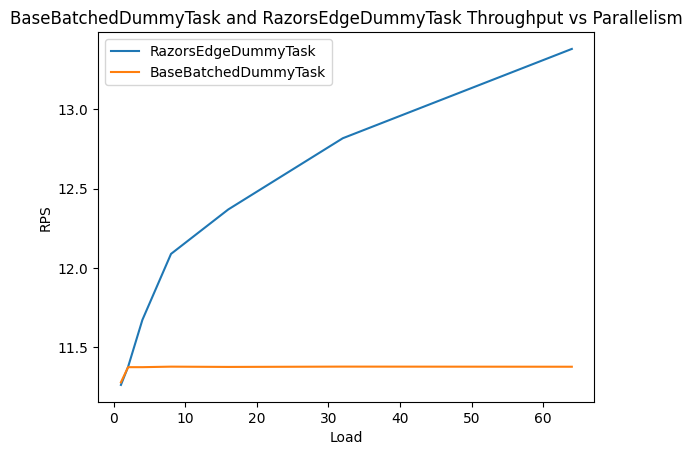

In [7]:
plt.bar(parallelism_limits, razors_edge_rps_list)
plt.plot(parallelism_limits, razors_edge_rps_list)
plt.ylabel("RPS")
plt.xlabel("Load")
plt.title("RazorsEdgeDummyTask Throughput vs Parallelism")
plt.savefig(Path("..") / ".." / "images" / f"{plt.gca().get_title()}.png", bbox_inches='tight')
plt.show()


plt.bar(parallelism_limits, basic_rps_list)
plt.plot(parallelism_limits, basic_rps_list)
plt.ylabel("RPS")
plt.xlabel("Load")
plt.title("BaseBatchedDummyTask Throughput vs Parallelism")
plt.savefig(Path("..") / ".." / "images" / f"{plt.gca().get_title()}.png", bbox_inches='tight')
plt.show()


plt.plot(parallelism_limits, razors_edge_rps_list, label = "RazorsEdgeDummyTask")
plt.plot(parallelism_limits, basic_rps_list, label = "BaseBatchedDummyTask")
plt.legend()
plt.ylabel("RPS")
plt.xlabel("Load")
plt.title("BaseBatchedDummyTask and RazorsEdgeDummyTask Throughput vs Parallelism")
plt.legend()
plt.savefig(Path("..") / ".." / "images" / f"{plt.gca().get_title()}.png", bbox_inches='tight')
plt.show()

In [8]:
print(max(razors_edge_rps_list), max(basic_rps_list), max(razors_edge_rps_list)/ max(basic_rps_list))

13.380289049306496 11.378298400173275 1.1759481583909537
